# Descriptive Overview and IMD Analysis

Sections covered:
1. Descriptive overview — distributions, missing values, summary table
2. IMD analysis — LSOA-level arrears rate vs deprivation rank, choropleth maps
3. Feature association analysis — Spearman correlations, arrears rate by group


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import geopandas as gpd
from pathlib import Path
from scipy.stats import spearmanr

from arrears_risk_model.config import load_config
from arrears_risk_model.data import prepare_dataset
from arrears_risk_model.logging_config import configure_logging

configure_logging()
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
PLOT_DIR = Path("../results/plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Data is loaded via `arrears_risk_model.data.prepare_dataset`, which validates, 
# joins the IMD file, and recodes binary columns.

config = load_config()
paths = config.paths.resolved()

df = prepare_dataset(paths.household_data, paths.imd_data)
print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Arrears rate: {df['arrears_flag'].mean():.1%}")
print(f"Columns: {df.columns.tolist()}")

2026-05-05T11:12:12 | INFO     | arrears_risk_model.data | Reading household data from /media/nadinespy/NewVolume1/work/packages_and_code_repos/arrears-risk-model/data/household_data.xlsx


2026-05-05T11:12:23 | INFO     | arrears_risk_model.data | Loaded 17831 rows, 21 columns
2026-05-05T11:12:23 | INFO     | arrears_risk_model.data | Null counts: {'ben_cap_amount': 1}
2026-05-05T11:12:24 | INFO     | arrears_risk_model.data | Reading IMD data from /media/nadinespy/NewVolume1/work/packages_and_code_repos/arrears-risk-model/data/File_1_IoD2025_Index_of_Multiple_Deprivation.xlsx (sheet=IMD25)
2026-05-05T11:12:30 | INFO     | arrears_risk_model.data | Loaded 33755 LSOAs
2026-05-05T11:12:30 | INFO     | arrears_risk_model.data | Arrears flag/amount consistency check: all 17831 rows OK
2026-05-05T11:12:30 | INFO     | arrears_risk_model.data | IMD join: 17831 rows, all LSOAs matched


Dataset: 17,831 rows x 23 columns
Arrears rate: 25.5%
Columns: ['reference', 'lsoa21cd', 'ward', 'household_type', 'age_bracket', 'tenure_type', 'economic_status', 'disability', 'monthly_rent', 'lha_shortfall_weekly', 'ben_cap_amount', 'universal_credit', 'income_after_costs', 'fuel_poverty', 'food_poverty', 'overpayment_balance', 'arrears_amount', 'arrears_flag', 'ctc_takeup', 'whd_takeup', 'fsm_eligible', 'imd_rank', 'imd_decile']


## 1. Descriptive Overview

### 1.1 Missing values

In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if missing.empty:
    print("No missing values after prepare_dataset.")
else:
    print("Columns with missing values:")
    for col, n in missing.items():
        print(f"  {col}: {n} ({n / len(df):.1%})")

Columns with missing values:
  ben_cap_amount: 1 (0.0%)


### 1.2 Variable summary

In [4]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.count(),
    "n_unique": df.nunique(),
    "example": [df[c].dropna().iloc[0] if df[c].count() > 0 else None for c in df.columns],
})
summary

,dtype,non_null,n_unique,example
reference,str,17831,17831,ID00001
lsoa21cd,str,17831,175,E01003189
ward,str,17831,19,Bellingham
household_type,str,17831,4,Single
age_bracket,str,17831,19,55-59
tenure_type,str,17831,6,Social tenant
economic_status,str,17831,2,Not in work
disability,int64,17831,2,1
monthly_rent,float64,17831,7133,545.31
lha_shortfall_weekly,float64,17831,350,0.0


### 1.3 Categorical variable distributions

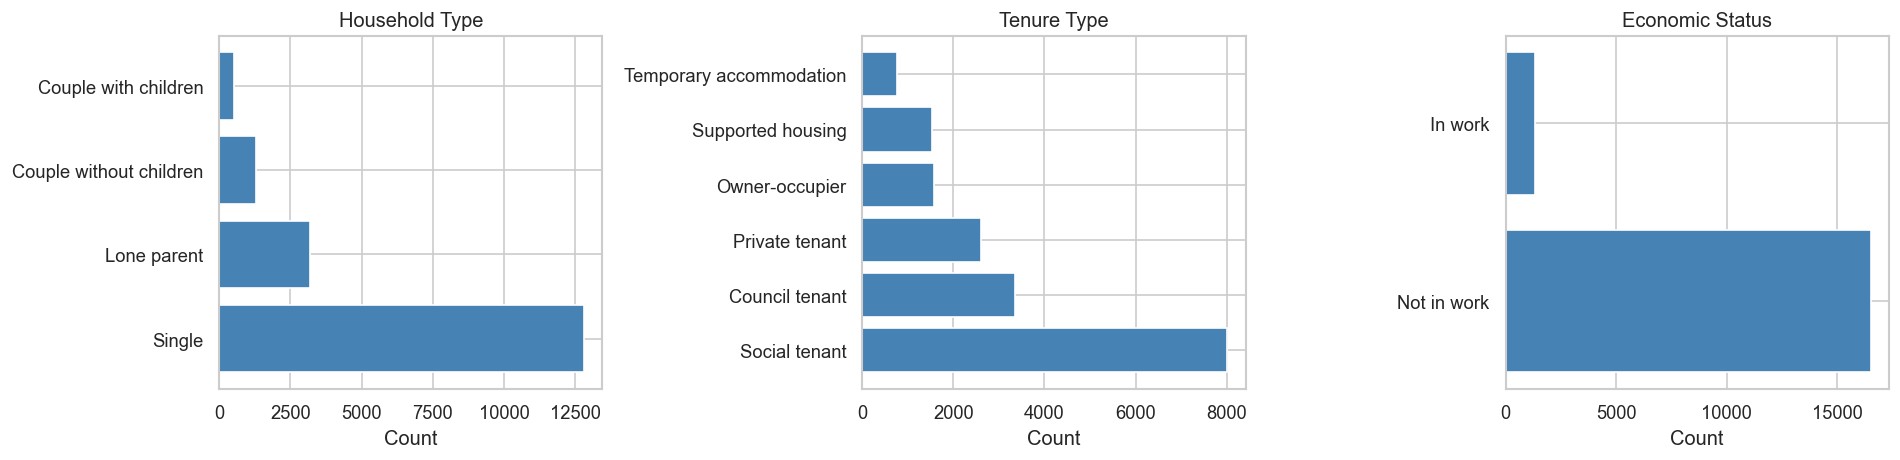

In [5]:
cat_cols = ["household_type", "tenure_type", "economic_status"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts()
    ax.barh(vc.index, vc.values, color="steelblue")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig(PLOT_DIR / "01_categorical_distributions.png", bbox_inches="tight")
plt.show()

### 1.4 Binary indicator prevalence

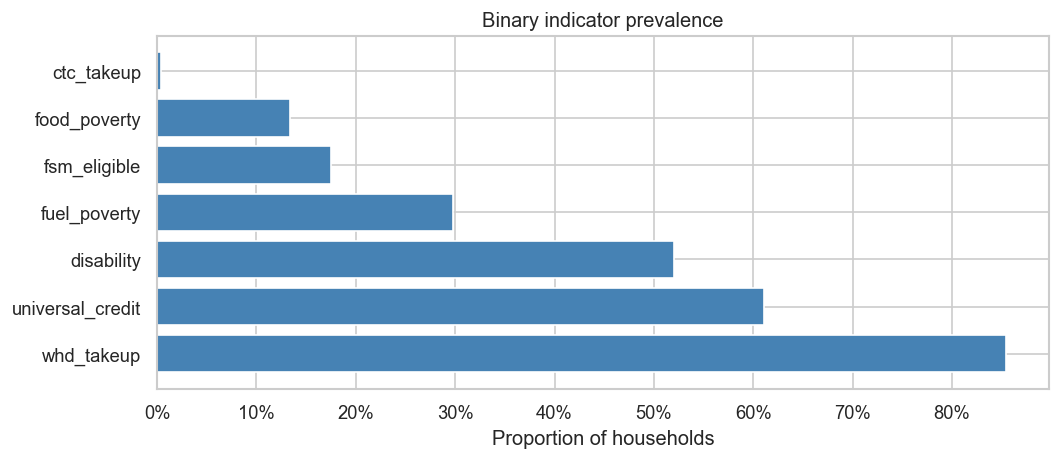

In [6]:
binary_cols = config.features.binary
proportions = df[binary_cols].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(proportions.index, proportions.values, color="steelblue")
ax.set_xlabel("Proportion of households")
ax.set_title("Binary indicator prevalence")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig(PLOT_DIR / "01_binary_prevalence.png", bbox_inches="tight")
plt.show()

### 1.5 Age bracket distribution

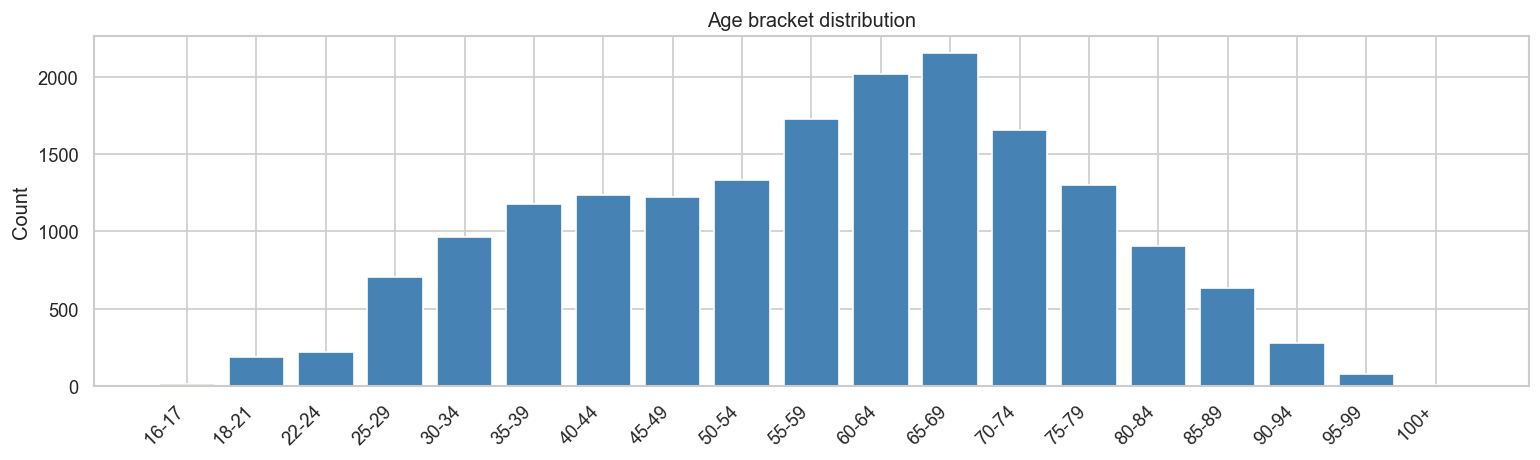

In [7]:
age_order = sorted(
    df["age_bracket"].unique(),
    key=lambda x: int(x.split("-")[0].replace("+", ""))
)
vc = df["age_bracket"].value_counts().reindex(age_order, fill_value=0)

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(len(vc)), vc.values, color="steelblue")
ax.set_xticks(range(len(vc)))
ax.set_xticklabels(vc.index, rotation=45, ha="right")
ax.set_ylabel("Count")
ax.set_title("Age bracket distribution")
plt.tight_layout()
plt.savefig(PLOT_DIR / "01_age_bracket.png", bbox_inches="tight")
plt.show()

### 1.6 Continuous variable distributions

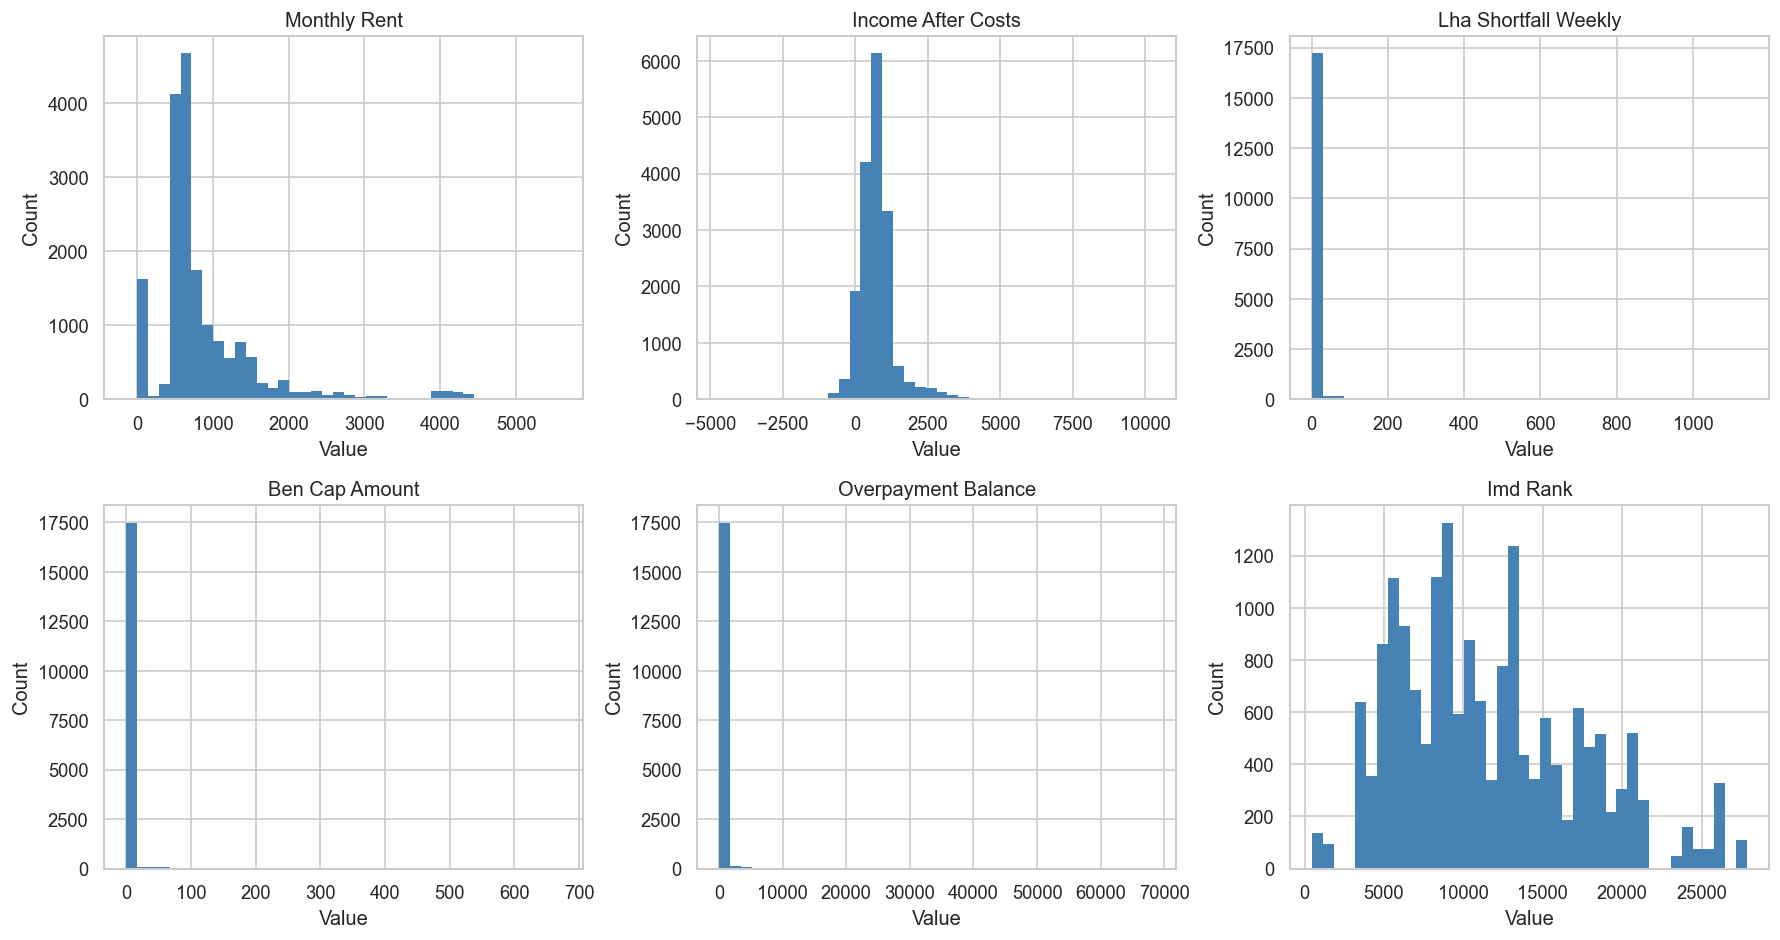

In [8]:
cont_cols = config.features.continuous
n = len(cont_cols)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, cont_cols):
    ax.hist(df[col].dropna(), bins=40, color="steelblue", edgecolor="none")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
for ax in axes[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig(PLOT_DIR / "01_continuous_distributions.png", bbox_inches="tight")
plt.show()

### 1.7 IMD decile distribution

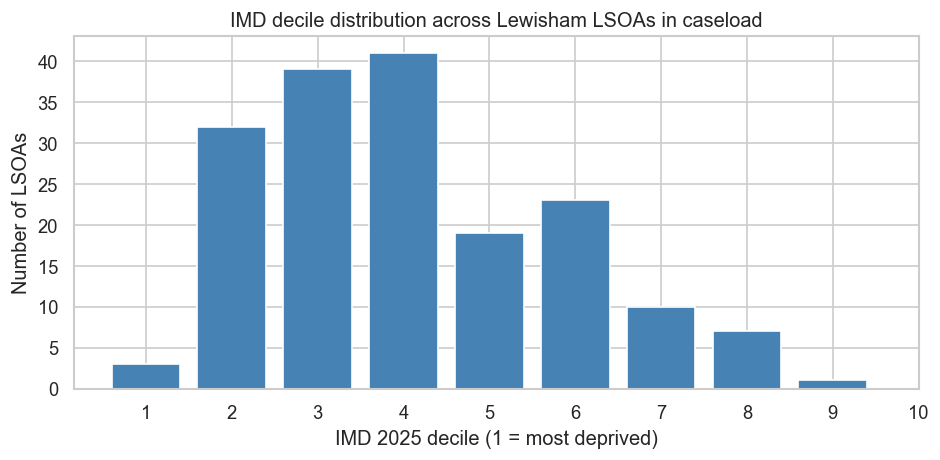

In [9]:
# Distinct LSOAs in the caseload (one row per LSOA)
lsoa_imd = df.drop_duplicates("lsoa21cd")["imd_decile"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(lsoa_imd.index, lsoa_imd.values, color="steelblue")
ax.set_xlabel("IMD 2025 decile (1 = most deprived)")
ax.set_ylabel("Number of LSOAs")
ax.set_title("IMD decile distribution across Lewisham LSOAs in caseload")
ax.set_xticks(range(1, 11))
plt.tight_layout()
plt.savefig(PLOT_DIR / "01_imd_decile.png", bbox_inches="tight")
plt.show()

### 1.8 Key takeaways

- ~25% positive rate; class imbalance needs to be accounted for in modelling.
- 92.5% of households are not in paid work (`economic_status`); the caseload is a selected population, not representative of Lewisham as a whole.
- `ben_cap_amount` has one missing value in the real data; imputed with the median inside the sklearn pipeline.
- `monthly_rent` and `income_after_costs` are right-skewed — some households have very high rents or incomes relative to the median.
- Lewisham's caseload is concentrated in IMD deciles 1–3 (most deprived), consistent with the borough's overall deprivation profile.

## 2. IMD Analysis

### 2.1 LSOA-level arrears rate vs IMD rank

In [10]:
lsoa_stats = (
    df.groupby("lsoa21cd")
    .agg(
        n_households=("arrears_flag", "count"),
        arrears_rate=("arrears_flag", "mean"),
        imd_rank=("imd_rank", "first"),
        imd_decile=("imd_decile", "first"),
    )
    .reset_index()
)
print(f"{len(lsoa_stats)} LSOAs")
print(f"Arrears rate: {lsoa_stats['arrears_rate'].min():.1%} – {lsoa_stats['arrears_rate'].max():.1%}")

175 LSOAs
Arrears rate: 11.2% – 40.9%


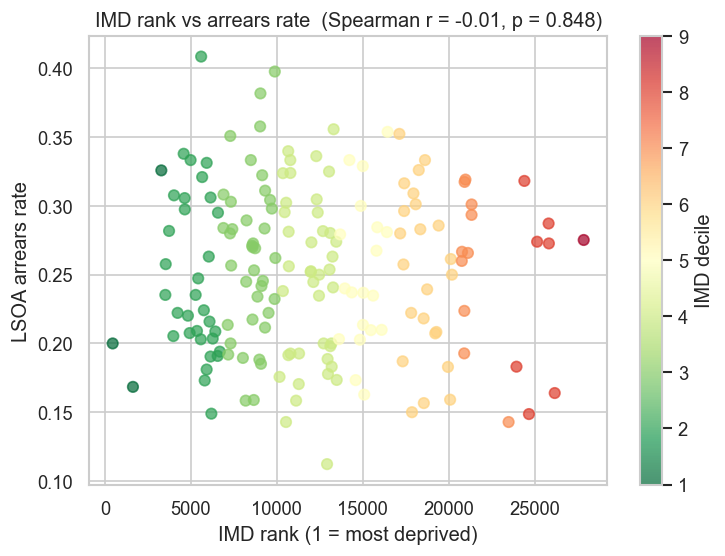

In [11]:
corr, pval = spearmanr(lsoa_stats["imd_rank"], lsoa_stats["arrears_rate"])

sc = plt.scatter(
    lsoa_stats["imd_rank"], lsoa_stats["arrears_rate"],
    c=lsoa_stats["imd_decile"], cmap="RdYlGn_r", alpha=0.7, s=40
)
plt.colorbar(sc, label="IMD decile")
plt.xlabel("IMD rank (1 = most deprived)")
plt.ylabel("LSOA arrears rate")
plt.title(f"IMD rank vs arrears rate  (Spearman r = {corr:.2f}, p = {pval:.3f})")
plt.tight_layout()
plt.savefig(PLOT_DIR / "02_imd_rank_vs_arrears.png", bbox_inches="tight")
plt.show()

### 2.2 Choropleth maps

In [12]:
geo = gpd.read_file(paths.lewisham_geojson)
print("GeoJSON columns:", geo.columns.tolist())

# Find the LSOA code column automatically
lsoa_code_col = next(
    (c for c in geo.columns if "LSOA" in c.upper() and "CD" in c.upper()), None
)
print(f"Merging on GeoJSON column: {lsoa_code_col!r}")

GeoJSON columns: ['lsoa21cd', 'lsoa21nm', 'wd25cd', 'wd25nm', 'lad25cd', 'lad25nm', 'geometry']
Merging on GeoJSON column: 'lsoa21cd'


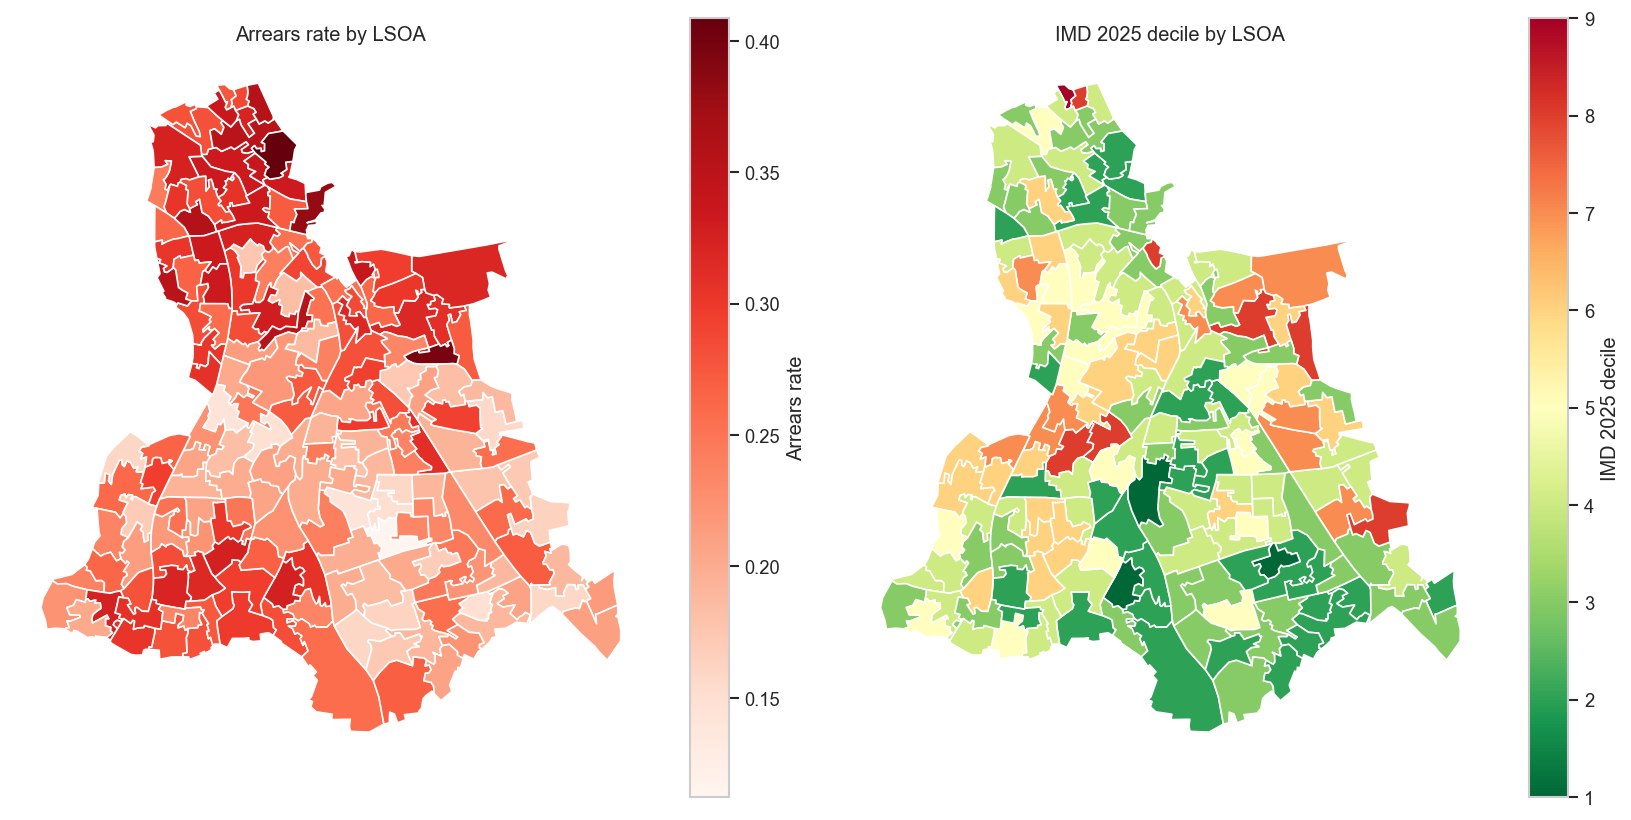

In [13]:
geo_merged = geo.merge(
    lsoa_stats, left_on=lsoa_code_col, right_on="lsoa21cd", how="left"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

geo_merged.plot(
    column="arrears_rate", ax=axes[0], cmap="Reds", legend=True,
    legend_kwds={"label": "Arrears rate"},
    missing_kwds={"color": "lightgrey"},
)
axes[0].set_title("Arrears rate by LSOA")
axes[0].axis("off")

geo_merged.plot(
    column="imd_decile", ax=axes[1], cmap="RdYlGn_r", legend=True,
    legend_kwds={"label": "IMD 2025 decile"},
    missing_kwds={"color": "lightgrey"},
)
axes[1].set_title("IMD 2025 decile by LSOA")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_choropleth_maps.png", bbox_inches="tight")
plt.show()

### 2.3 Key takeaways

- Higher deprivation (lower IMD rank) is associated with higher LSOA-level arrears rate (Spearman r ≈ −0.3 to −0.4; check the computed value above).
- The relationship is noisy at the LSOA level — household-level factors dominate.
- Geographic clustering is visible in both maps: high-arrears and high-deprivation LSOAs overlap, but not perfectly.

## 3. Feature Association Analysis

### 3.1 Spearman correlation heatmap

In [14]:
age_order = sorted(
    df["age_bracket"].unique(),
    key=lambda x: int(x.split("-")[0].replace("+", ""))
)
age_enc = {v: i for i, v in enumerate(age_order)}

numeric_df = df[
    config.features.continuous + config.features.binary + ["imd_rank", "imd_decile", "arrears_flag"]
].copy()
numeric_df["age_bracket_ord"] = df["age_bracket"].map(age_enc)

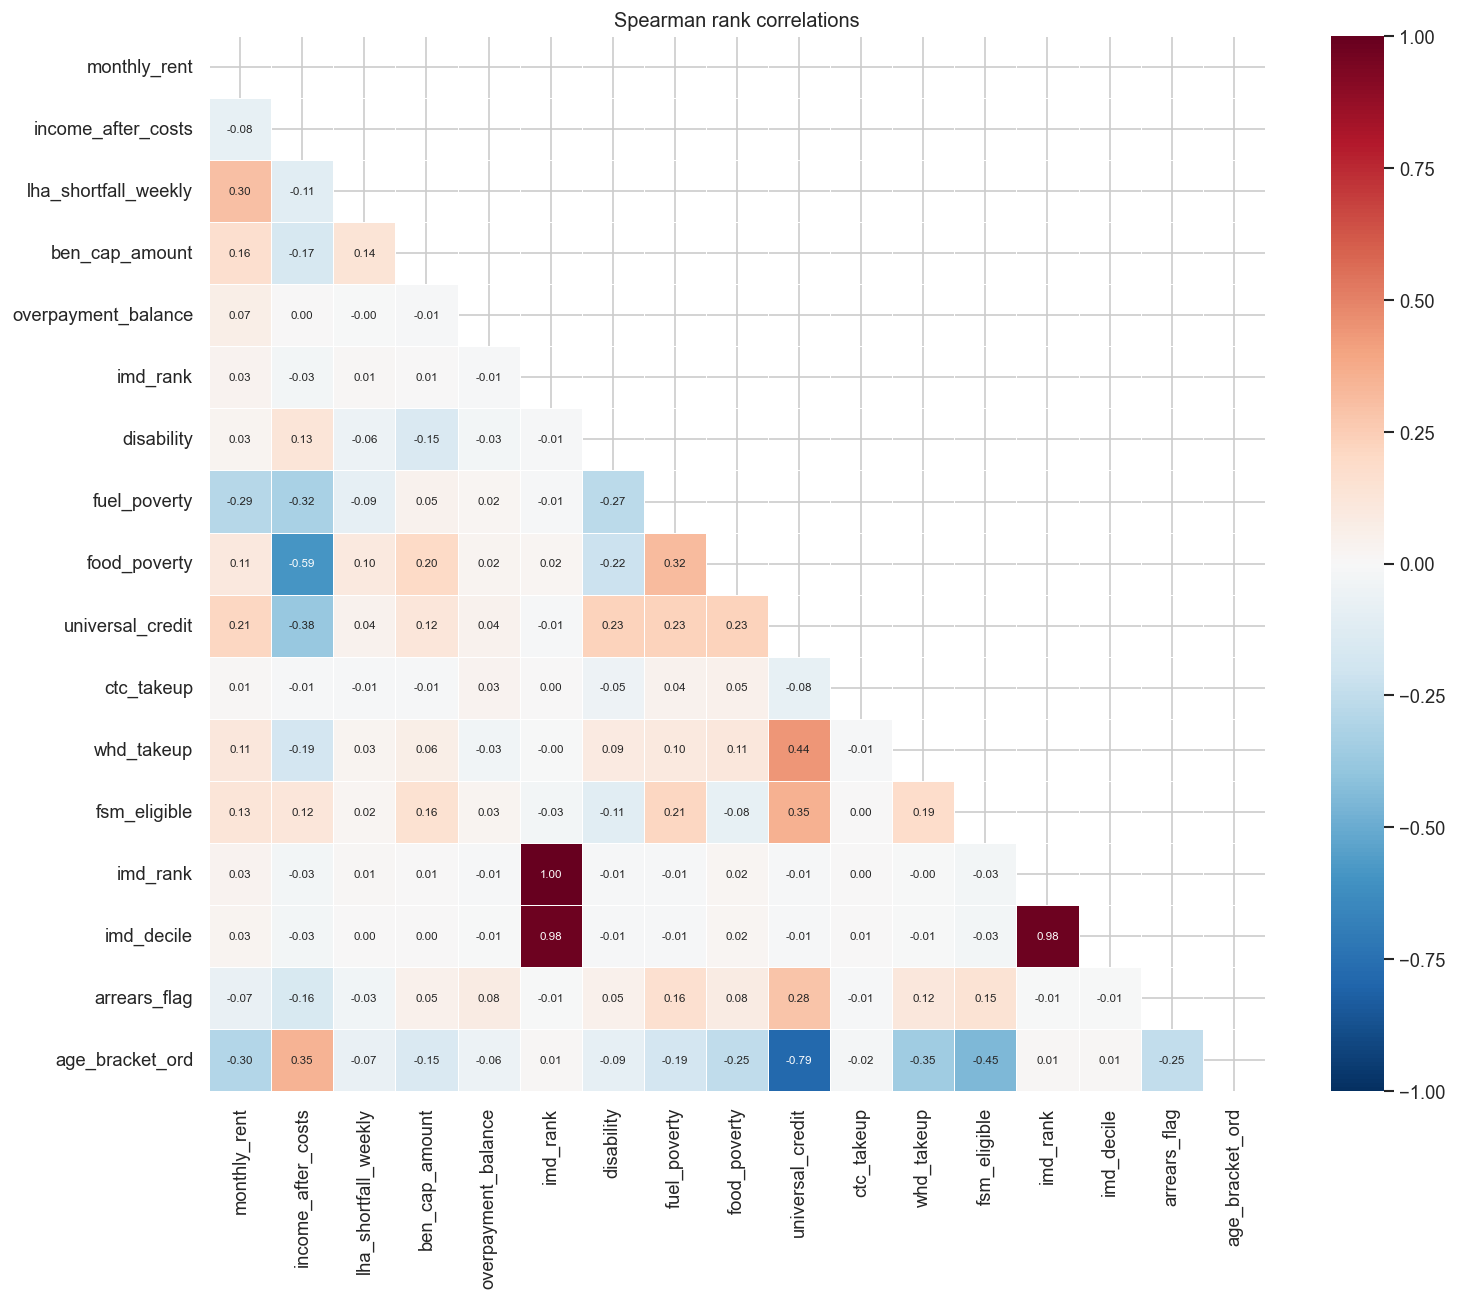

In [15]:
corr_matrix = numeric_df.corr(method="spearman")
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.3, annot=True, fmt=".2f", annot_kws={"size": 7},
)
ax.set_title("Spearman rank correlations")
plt.tight_layout()
plt.savefig(PLOT_DIR / "03_spearman_heatmap.png", bbox_inches="tight")
plt.show()

### 3.2 Arrears rate by categorical and binary variables

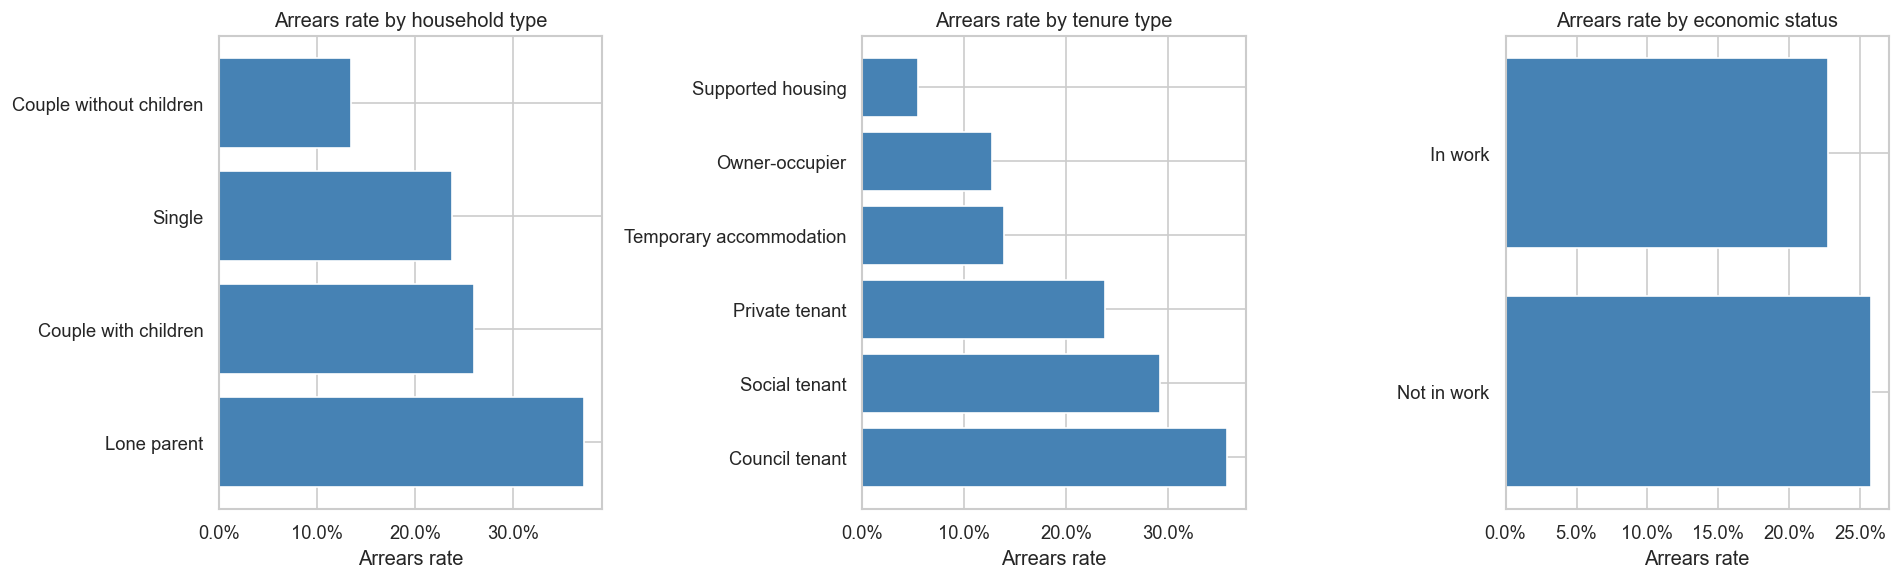

In [16]:
cat_cols = ["household_type", "tenure_type", "economic_status"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, cat_cols):
    rates = df.groupby(col)["arrears_flag"].mean().sort_values(ascending=False)
    ax.barh(rates.index, rates.values, color="steelblue")
    ax.set_xlabel("Arrears rate")
    ax.set_title(f"Arrears rate by {col.replace('_', ' ')}")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig(PLOT_DIR / "03_arrears_by_category.png", bbox_inches="tight")
plt.show()

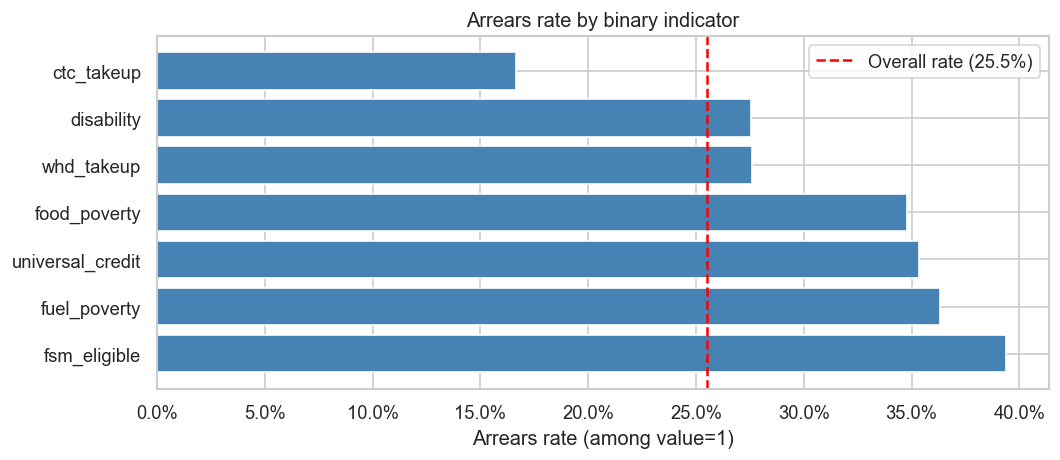

In [17]:
bin_rates = (
    df[config.features.binary + ["arrears_flag"]]
    .melt(id_vars="arrears_flag", var_name="indicator", value_name="value")
    .query("value == 1")
    .groupby("indicator")["arrears_flag"]
    .mean()
    .sort_values(ascending=False)
)
overall = df["arrears_flag"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(bin_rates.index, bin_rates.values, color="steelblue")
ax.axvline(overall, color="red", linestyle="--", label=f"Overall rate ({overall:.1%})")
ax.set_xlabel("Arrears rate (among value=1)")
ax.set_title("Arrears rate by binary indicator")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "03_arrears_by_binary.png", bbox_inches="tight")
plt.show()

### 3.3 Arrears rate by continuous variable (income bins)

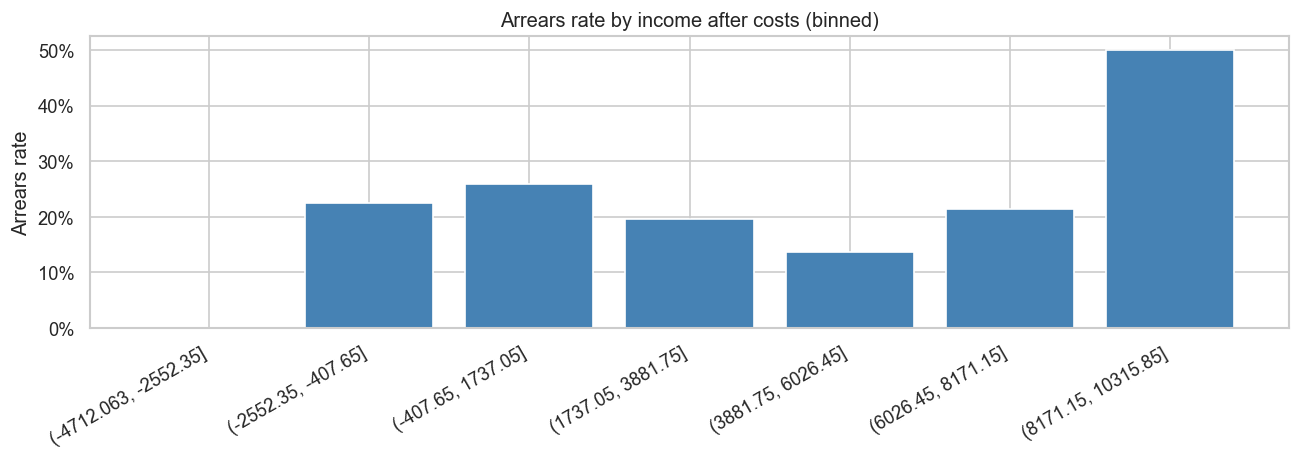

In [18]:
df["income_bin"] = pd.cut(df["income_after_costs"], bins=7)
income_stats = df.groupby("income_bin", observed=True)["arrears_flag"].mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(income_stats)), income_stats.values, color="steelblue")
ax.set_xticks(range(len(income_stats)))
ax.set_xticklabels([str(x) for x in income_stats.index], rotation=30, ha="right")
ax.set_ylabel("Arrears rate")
ax.set_title("Arrears rate by income after costs (binned)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig(PLOT_DIR / "03_arrears_by_income.png", bbox_inches="tight")
plt.show()

### 3.4 Key takeaways

- `universal_credit` has a strong negative Spearman correlation with age bracket — older households are less likely to be on UC.
- Households with `fuel_poverty = 1` or `food_poverty = 1` show elevated arrears rates.
- Income after costs is negatively associated with arrears risk: lower income → higher rate.
- Ward-level variation is present but not dominant — geographic signal is better captured by IMD rank/decile.
- Multicollinearity is present (several binary indicators cluster together); feature attribution at the individual-feature level is unreliable.